# scikit-learn estimator - `NonlineRegressor`

`NonlineRegressor` wraps the LSI / EAC / DSB methods behind the standard
estimator API (`fit` / `predict` / `score`), so it composes with `Pipeline`,
`GridSearchCV` and `cross_val_score`. It takes a single input feature (the
model's variable).

In [1]:
%matplotlib inline
import warnings
import numpy as np
import matplotlib.pyplot as plt

# Fitting at extreme parameter trials can overflow exp() harmlessly; keep the
# guide output clean.
warnings.filterwarnings("ignore", category=RuntimeWarning)

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
rng = np.random.default_rng(0)

## Fit / predict / score

coef_ : [1.4081 0.7974]
R2    : 0.9986


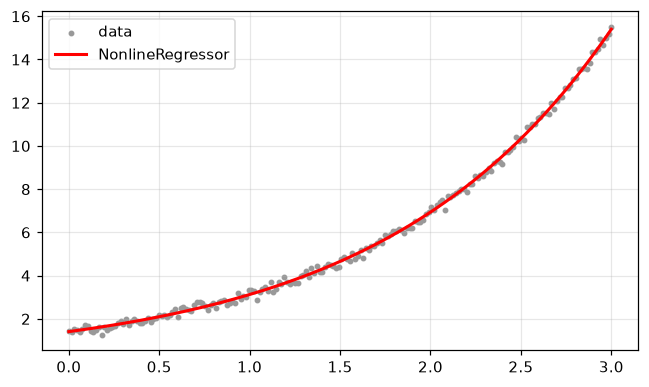

In [2]:
from dtfit import NonlineRegressor

X = np.linspace(0, 3, 200).reshape(-1, 1)
y = 1.4 * np.exp(0.8 * X.ravel()) + rng.normal(0, 0.15, X.shape[0])

reg = NonlineRegressor("a*exp(b*x)", "x", method="lsi").fit(X, y)
print("coef_ :", np.round(reg.coef_, 4))
print("R2    :", round(reg.score(X, y), 4))

xs = np.linspace(0, 3, 300).reshape(-1, 1)
plt.scatter(X, y, s=8, color="0.6", label="data")
plt.plot(xs.ravel(), reg.predict(xs), "r-", lw=2, label="NonlineRegressor")
plt.legend(); plt.show()

## Hyperparameter search with `GridSearchCV`

Treat the method and spectral order as hyperparameters; sklearn does the rest.

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([("fit", NonlineRegressor("a0 + a1*exp(a2*x)", "x"))])
grid = GridSearchCV(
    pipe,
    {"fit__method": ["lsi", "eac"], "fit__k_star": [4, 6]},
    cv=3, scoring="r2",
)
grid.fit(X, y)
print("best params:", grid.best_params_)
print("best CV R2 :", round(grid.best_score_, 4))

best params: {'fit__k_star': 4, 'fit__method': 'lsi'}
best CV R2 : 0.9674


## Cross-validation

In [4]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    NonlineRegressor("a*exp(b*x)", "x"), X, y, cv=4, scoring="r2"
)
print("per-fold R2:", np.round(scores, 3))
print("mean R2    :", round(scores.mean(), 4))

per-fold R2: [0.885 0.936 0.983 0.995]
mean R2    : 0.9498
